<a href="https://colab.research.google.com/github/aryalankit121/Data-Visualization-App/blob/main/Notebook_2_Prototype_311_Dashboard_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 2: Prototype Your 311 Dashboard

## Purpose
Before you build a Streamlit application, make sure the **date filtering and charts work in Python**.

This notebook intentionally stays simple. You will:
1. Read the reduced file created in Notebook 1.
2. Choose a start date and end date within 2025.
3. Filter the data to those dates.
4. Display **two simple charts**.
5. Replace the sample charts with two charts you want to use in your own dashboard.

Later, ChatGPT can help you turn this working logic into `app.py`.


## 1. Import the libraries and read your reduced dataset


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

DATA_FILE = "311_2025_dashboard.csv"

df = pd.read_csv(DATA_FILE)
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
df.head()


Rows: 250,933
Columns: 9


,service_request_id,service_type,agency_responsible,status,request_date,day_of_week,resolution_days,lat,lon
0,17346520,Graffiti Removal,Community Life Improvement Program,Closed,2025-01-01,Wednesday,6.536690,39.963169,-75.166457
1,17346521,Graffiti Removal,Community Life Improvement Program,Closed,2025-01-01,Wednesday,6.533762,39.963625,-75.169500
2,17346523,Recyclables Collection,Streets Department,Closed,2025-01-01,Wednesday,61.596366,39.978809,-75.239265
3,17346524,Graffiti Removal,Community Life Improvement Program,Closed,2025-01-01,Wednesday,6.529155,39.963703,-75.170116
4,17346525,Recyclables Collection,Streets Department,Closed,2025-01-01,Wednesday,2.470891,40.043401,-75.072138


## 2. Convert `request_date` back to a datetime
CSV files do not preserve pandas data types, so we convert this field after reading the file.


In [2]:
df["request_date"] = pd.to_datetime(df["request_date"], errors="coerce")

print("Available dates:")
print(df["request_date"].min(), "through", df["request_date"].max())


Available dates:
2025-01-01 00:00:00 through 2025-06-30 00:00:00


## 3. Select a start date and end date
For now, you will change two Python variables. **Change these dates and rerun the cells below.**

When you build the Streamlit application, these variables will become interactive date controls.


In [22]:
# CHANGE THESE DATES to explore a different part of 2025
START_DATE = "2025-03-01"
END_DATE = "2025-03-31"

start_date = pd.to_datetime(START_DATE)
end_date = pd.to_datetime(END_DATE)

if start_date > end_date:
    raise ValueError("START_DATE must be on or before END_DATE.")


## 4. Filter the DataFrame
This is the core idea that your Streamlit dashboard will use.


In [23]:
filtered_df = df[
    (df["request_date"] >= start_date) &
    (df["request_date"] <= end_date)
].copy()

print(f"Selected period: {START_DATE} through {END_DATE}")
print(f"Requests in selected period: {len(filtered_df):,}")


Selected period: 2025-03-01 through 2025-03-31
Requests in selected period: 42,893


## 5. Sample Chart 1: Top Request Types
This is intentionally a basic bar chart. Your final dashboard does not have to use this chart.


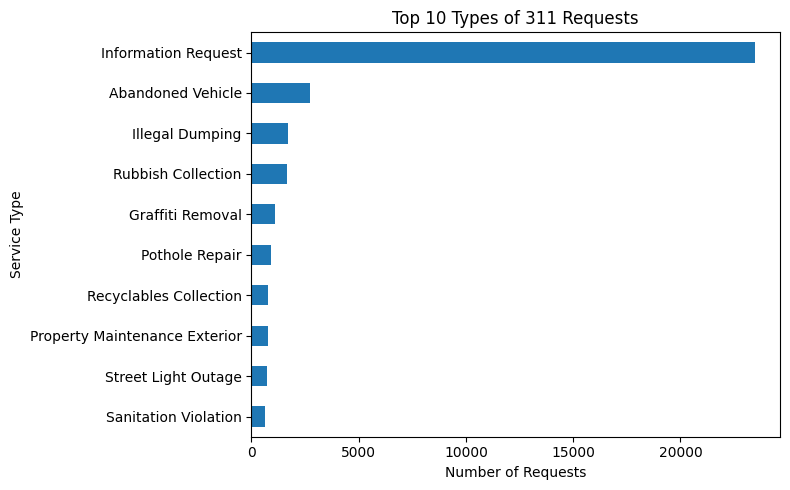

In [24]:
top_requests = (
    filtered_df["service_type"]
    .value_counts()
    .head(10)
    .sort_values()
)

ax = top_requests.plot(
    kind="barh",
    figsize=(8, 5),
    title="Top 10 Types of 311 Requests"
)
ax.set_xlabel("Number of Requests")
ax.set_ylabel("Service Type")
plt.tight_layout()
plt.show()


## 6. Sample Chart 2: Requests Over Time
This chart groups requests by day. Again, keep the idea simple: **filter first, summarize second, chart third**.


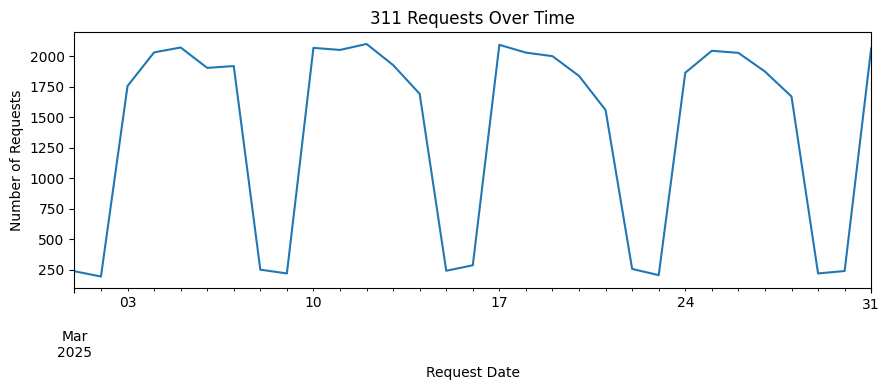

In [25]:
requests_by_day = (
    filtered_df
    .groupby("request_date")
    .size()
)

ax = requests_by_day.plot(
    kind="line",
    figsize=(9, 4),
    title="311 Requests Over Time"
)
ax.set_xlabel("Request Date")
ax.set_ylabel("Number of Requests")
plt.tight_layout()
plt.show()


## 7. Your Turn: Replace the Examples
Create **two charts of your choice** using `filtered_df`.

Your charts should answer useful questions about the 311 data. Possibilities include:
- most common service types;
- requests handled by different agencies;
- requests by ZIP code;
- requests over time;
- status of requests;
- resolution time, if you included that variable;
- another meaningful pattern you found during your EDA.

Keep the visualizations straightforward. A clear bar chart or line chart is often better than a complicated visualization.


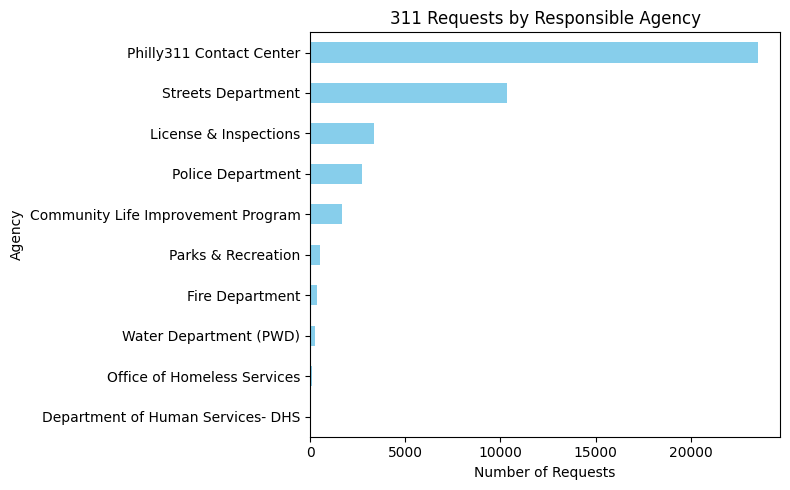

In [26]:
# YOUR CHART 1
# CHART 1: Workload by Responsible Agency
agency_counts = (
    filtered_df["agency_responsible"]
    .value_counts()
    .head(10)
    .sort_values()
)

ax = agency_counts.plot(
    kind="barh",
    figsize=(8, 5),
    color="skyblue"
)
ax.set_title("311 Requests by Responsible Agency")
ax.set_xlabel("Number of Requests")
ax.set_ylabel("Agency")
plt.tight_layout()
plt.show()


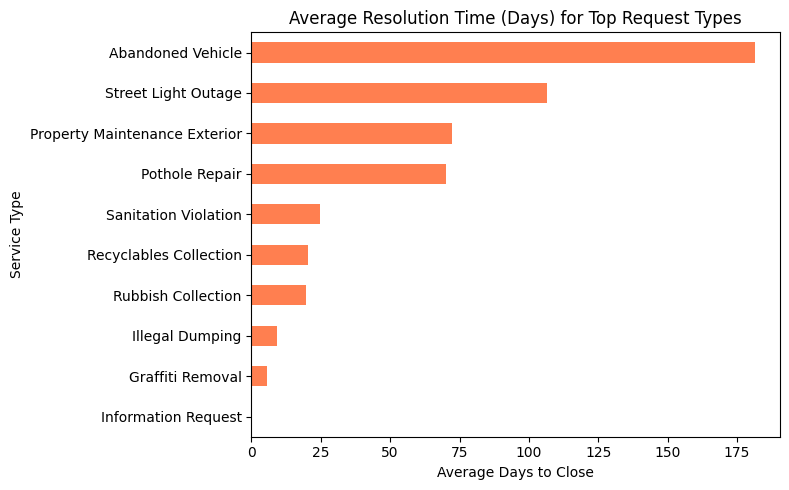

In [27]:
# YOUR CHART 2
# CHART 2: Average Resolution Time (Days) by Service Type
# 1. Identify the top 10 service types by volume
top_services = filtered_df["service_type"].value_counts().head(10).index

# 2. Calculate mean resolution days for those top service types
avg_res_time = (
    filtered_df[filtered_df["service_type"].isin(top_services)]
    .groupby("service_type")["resolution_days"]
    .mean()
    .sort_values()
)

ax = avg_res_time.plot(
    kind="barh",
    figsize=(8, 5),
    color="coral"
)
ax.set_title("Average Resolution Time (Days) for Top Request Types")
ax.set_xlabel("Average Days to Close")
ax.set_ylabel("Service Type")
plt.tight_layout()
plt.show()


## 8. Test Your Date Filter
Before moving on:
1. Change `START_DATE` and `END_DATE` near the top of the notebook.
2. Rerun the filter and chart cells.
3. Confirm that the number of records and charts change.

If that works, you have the core logic for your Streamlit dashboard.


# Next Step: Turn This into Streamlit
Once your two charts work, you may use ChatGPT to help create `app.py`.

A useful starting prompt is:

> I have a Python notebook that reads a reduced 2025 311 dataset. It uses START_DATE and END_DATE variables to filter request_date, and I have two working charts based on the filtered DataFrame. Help me create a simple Streamlit app.py that replaces START_DATE and END_DATE with Streamlit date controls. Keep my analysis and charts simple. Explain the code so I understand it.

Then work with ChatGPT to add the other charts, metrics, and controls required by the assignment.

**Important:** Test the code ChatGPT gives you. You are responsible for understanding what your application does and for submitting a working dashboard.
